In [1]:
!pip install bnlp_toolkit
!pip install banglanltk

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.layers import Bidirectional
from PIL import Image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,GRU,Bidirectional
from wordcloud import WordCloud, STOPWORDS
from bnlp.corpus import stopwords, punctuations
from nltk.corpus import stopwords as nltk_stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import cv2
import csv
from keras.layers import Dropout
import gensim
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk
import matplotlib.font_manager as fm
import banglanltk as bn
import re
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
import string
import emoji
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import confusion_matrix,classification_report
%matplotlib inline 



/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: l

# Read Image Mask And Bangla Font

In [3]:
my_image=np.array(Image.open("/kaggle/input/wodcloud-twiter-pic/twitter.png"))
my_font="/kaggle/input/wodcloud-twiter-pic/kalpurush.ttf"

# Read Real Data

In [4]:
real_data=pd.read_csv("/kaggle/input/banfakenews/Authentic-48K.csv")
real_data.head()

,articleID,domain,date,category,headline,content,label
0,1,jagonews24.com,2018-09-19 17:48:18,Education,"হট্টগোল করায় বাকৃবিতে দুইজন বরখাস্ত, ৬ জনকে শোকজ",গত ১৭ সেপ্টেম্বর বাংলাদেশ কৃষি বিশ্ববিদ্যালয়ে ...,1
1,2,jagonews24.com,2018-09-19 17:48:19,National,মালয়েশিয়ায় কর্মী পাঠানোর ব্যবস্থা নেয়ার সুপারিশ,বাংলাদেশের বৃহৎ শ্রমবাজার মালয়েশিয়ায় আবার শ্রম...,1
2,3,jagonews24.com,2018-09-19 17:48:20,National,প্রেমের প্রস্তাবে রাজি না হওয়ায় স্কুলছাত্রীকে ...,নরসিংদীর মনোহরদীতে প্রেমের প্রস্তাবে রাজি না হ...,1
3,4,jagonews24.com,2018-09-19 17:48:21,Crime,মেডিয়েশনই মামলাজট নিরসনের পথ : বিচারপতি আহমেদ ...,সুপ্রিম কোর্টের হাইকোর্ট বিভাগের বিচারপতি আহমে...,1
4,5,jagonews24.com,2018-09-19 17:48:21,National,টকশোতে বক্তব্য দিতে গিয়ে জাপা নেতার মৃত্যু,মাদারীপুর সদরের উপজেলার লেকেরপাড়ে একটি বেসরকার...,1


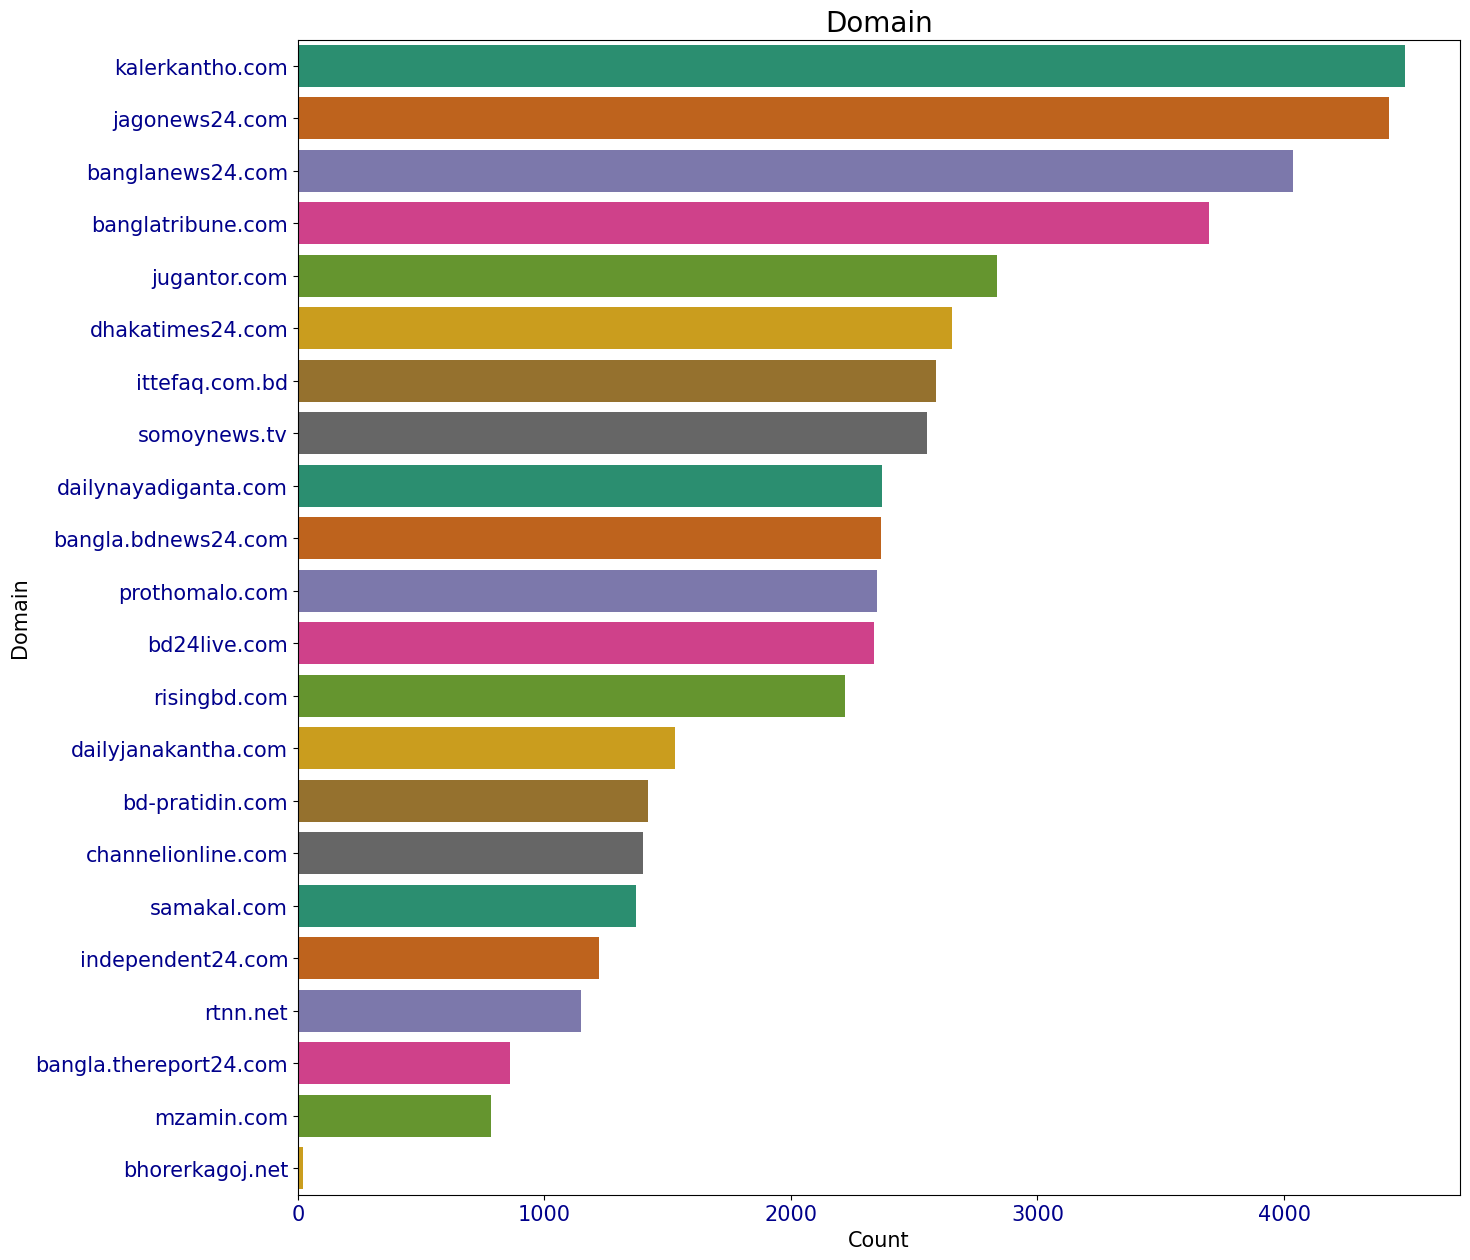

In [5]:
domain_counts = real_data['domain'].value_counts()
domain_order = domain_counts.index.tolist()

plt.figure(figsize=(15, 15))
sns.countplot(y="domain", data=real_data, palette="Dark2", order=domain_order)
plt.title("Domain",color="black",fontsize=20)
plt.xticks(fontsize=15,color="darkblue")
plt.yticks(fontsize=15,color="darkblue")
plt.xlabel("Count",fontsize=15,color="black")
plt.ylabel("Domain",fontsize=15,color="black")
plt.show()

# Read Fake Data

In [6]:
fake_data=pd.read_csv("/kaggle/input/banfakenews/Fake-1K.csv")
fake_data.head()

,articleID,domain,date,category,headline,content,label
0,1,channeldhaka.news,2019-03-14T13:34:14+00:00,International,মুরগির হামলায় শেয়াল নিহত,"বাংলায় একটা প্রবাদ আছে, শেয়ালের কাছে মুরগী বর্...",0
1,2,earki.com,"সেম্বর ১৭, ২০১৮",Miscellaneous,বিটিভিতে যেবার আমি ইন্টারভিউ দিতে গেলাম,"BTV থেকে লোকজন আসছে, ইন্টারভিউ নিবে।চারজনের টি...",0
2,3,earki.com,"২০:৩৯, জানুয়ারি ১৪, ২০১৯",Miscellaneous,বিদেশ থেকে উন্নতমানের বিরোধীদল আমদানি করার পরা...,অদ্ভুত বিরোধীদলহীনতায় ভুগছে সরকার। এ এক অন্যরক...,0
3,4,channeldhaka.news,2018-06-30T15:56:47+00:00,Sports,অবসর নেয়ার ঘোষণা দিলেন মেসি !,রাশিয়া বিশ্বকাপ নকআউট পর্বে ফ্রান্সের সাথে ৪-৩...,0
4,5,motikontho.wordpress.com,2013-03-05T21:55:45+00:00,Miscellaneous,"মাদারফাকার নহে, ব্রাদারফাকার: সাকা | দৈনিক মতি...","নিজস্ব মতিবেদক‘মাদারফাকার নহে, আমি ব্রাদারফাকা...",0


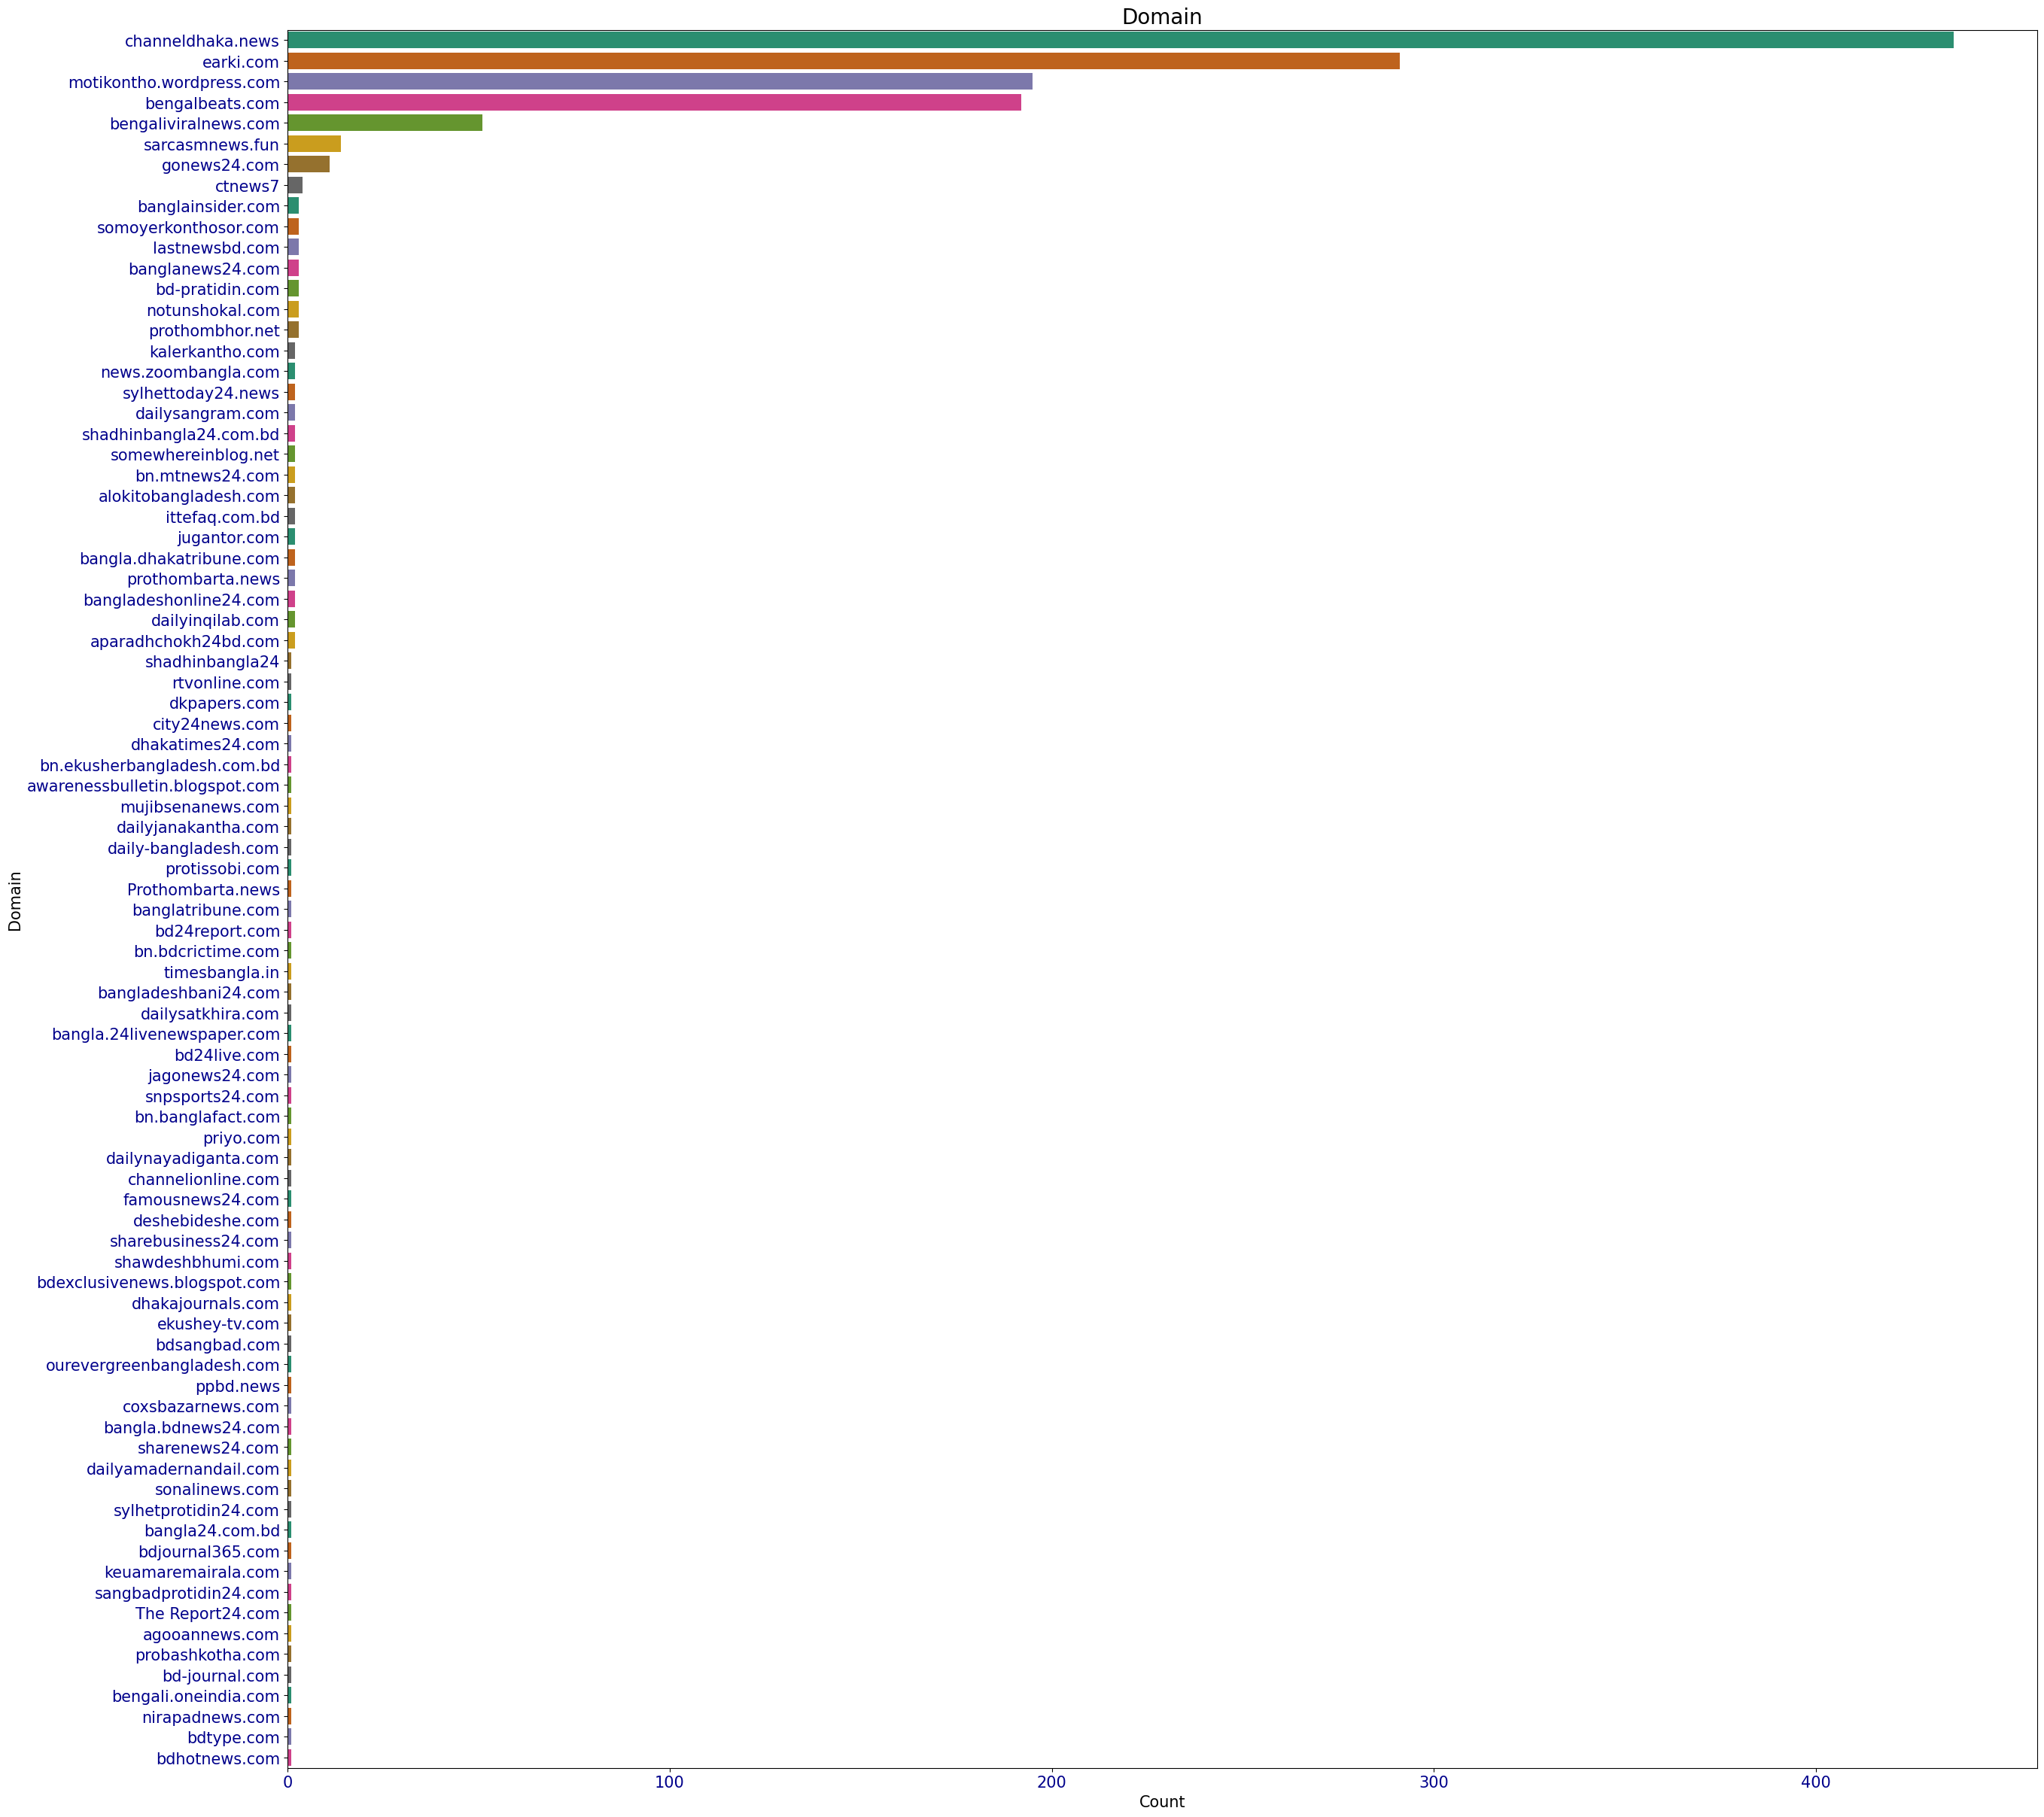

In [7]:
domain_counts = fake_data['domain'].value_counts()
domain_order = domain_counts.index.tolist()

plt.figure(figsize=(30,30))
sns.countplot(y="domain", data=fake_data, palette="Dark2", order=domain_order)
plt.title("Domain",color="black",fontsize=20)
plt.xticks(fontsize=15,color="darkblue")
plt.yticks(fontsize=15,color="darkblue")
plt.xlabel("Count",fontsize=15,color="black")
plt.ylabel("Domain",fontsize=15,color="black")
plt.show()

# Read Real Data Label

In [8]:
real_label=pd.read_csv("/kaggle/input/banfakenews/LabeledAuthentic-7K.csv")
real_label.head()

,articleID,domain,date,category,source,relation,headline,content,label
0,1,bd-pratidin.com,2018-09-20 08:16:43,Sports,আফগান ক্রিকেট বোর্ড (এসিবি) প্রধান,Related,হঠাৎ আফগান ক্রিকেট বোর্ড প্রধানের পদত্যাগ,ক্রিকেট বিশ্বের নতুন চমকের নাম আফগানিস্তান। কয়...,1.0
1,2,jugantor.com,2018-09-20 20:20:20,Sports,Reporter,Related,টস হেরে বোলিংয়ে বাংলাদেশ,এশিয়া কাপের ষষ্ঠ ম্যাচে বাংলাদেশ দলের বিপক্ষে ...,1.0
2,3,bd24live.com,2018-09-20 16:39:40,National,Reporter,Related,রাজধানীতে বিশেষ অভিযানে আটক ৪৩,রাজধানীতে মাদক বিরোধী বিশেষ অভিযান পরিচালনা কর...,1.0
3,4,bd24live.com,2018-09-19 18:27:56,National,জননিরাপত্তা বিভাগের সচিব,Related,উস্কানি রোধে নজরদারি থাকবে সামাজিক যোগাযোগ মাধ...,সনাতন ধর্মাবলম্বীদের সবচেয়ে বড় ধর্মীয় উৎসব দুর...,1.0
4,5,somoynews.tv,2018-09-20 10:15:28,Finance,পেট্রোল পাম্প মালিক সমিতি সভাপতি,Related,"'যেখানে তেল আসত ৭ দিনে, এখন তা আসবে অতি দ্রুত'",ভারত থেকে পাইপ লাইনের মাধ্যমে সরাসরি দেশে জ্বা...,1.0


# Read Fake Data Label

In [9]:
fake_label=pd.read_csv("/kaggle/input/banfakenews/LabeledFake-1K.csv")
fake_label.head()

,articleID,domain,date,category,source,relation,headline,content,label,F-type
0,1,channeldhaka.news,2019-03-14T13:34:14+00:00,International,Reporter,Unrelated,মুরগির হামলায় শেয়াল নিহত,"বাংলায় একটা প্রবাদ আছে, শেয়ালের কাছে মুরগী বর্...",0,Satire
1,2,earki.com,"সেম্বর ১৭, ২০১৮",Miscellaneous,Reporter,Unrelated,বিটিভিতে যেবার আমি ইন্টারভিউ দিতে গেলাম,"BTV থেকে লোকজন আসছে, ইন্টারভিউ নিবে।চারজনের টি...",0,Satire
2,3,earki.com,"২০:৩৯, জানুয়ারি ১৪, ২০১৯",Miscellaneous,Reporter,Unrelated,বিদেশ থেকে উন্নতমানের বিরোধীদল আমদানি করার পরা...,অদ্ভুত বিরোধীদলহীনতায় ভুগছে সরকার। এ এক অন্যরক...,0,Satire
3,4,channeldhaka.news,2018-06-30T15:56:47+00:00,Sports,Reporter,Unrelated,অবসর নেয়ার ঘোষণা দিলেন মেসি !,রাশিয়া বিশ্বকাপ নকআউট পর্বে ফ্রান্সের সাথে ৪-৩...,0,Satire
4,5,motikontho.wordpress.com,2013-03-05T21:55:45+00:00,Miscellaneous,Reporter,Unrelated,"মাদারফাকার নহে, ব্রাদারফাকার: সাকা | দৈনিক মতি...","নিজস্ব মতিবেদক‘মাদারফাকার নহে, আমি ব্রাদারফাকা...",0,Satire


# Analysis Data

In [10]:
fake_data.isnull()

,articleID,domain,date,category,headline,content,label
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1294,False,False,False,False,False,False,False
1295,False,False,False,False,False,False,False
1296,False,False,False,False,False,False,False
1297,False,False,False,False,False,False,False


In [11]:
fake_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1299 entries, 0 to 1298
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   articleID  1299 non-null   int64 
 1   domain     1299 non-null   object
 2   date       1299 non-null   object
 3   category   1299 non-null   object
 4   headline   1299 non-null   object
 5   content    1299 non-null   object
 6   label      1299 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 71.2+ KB


In [12]:
real_data.isnull()

,articleID,domain,date,category,headline,content,label
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
48673,False,False,False,False,False,False,False
48674,False,False,False,False,False,False,False
48675,False,False,False,False,False,False,False
48676,False,False,False,False,False,False,False


In [13]:
real_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48678 entries, 0 to 48677
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   articleID  48678 non-null  int64 
 1   domain     48678 non-null  object
 2   date       48678 non-null  object
 3   category   48678 non-null  object
 4   headline   48678 non-null  object
 5   content    48678 non-null  object
 6   label      48678 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.6+ MB


In [14]:
fake_data.shape

(1299, 7)

In [15]:
real_data.shape

(48678, 7)

# Count Fake Data Each Category

In [16]:
fake_data["category"].value_counts()

Miscellaneous    654
Entertainment    106
Lifestyle        102
National          99
International     91
Politics          90
Sports            54
Crime             42
Education         30
Technology        29
Finance            2
Name: category, dtype: int64

# Fake Data Category Visualize

/tmp/ipykernel_6361/4038474509.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-darkgrid")


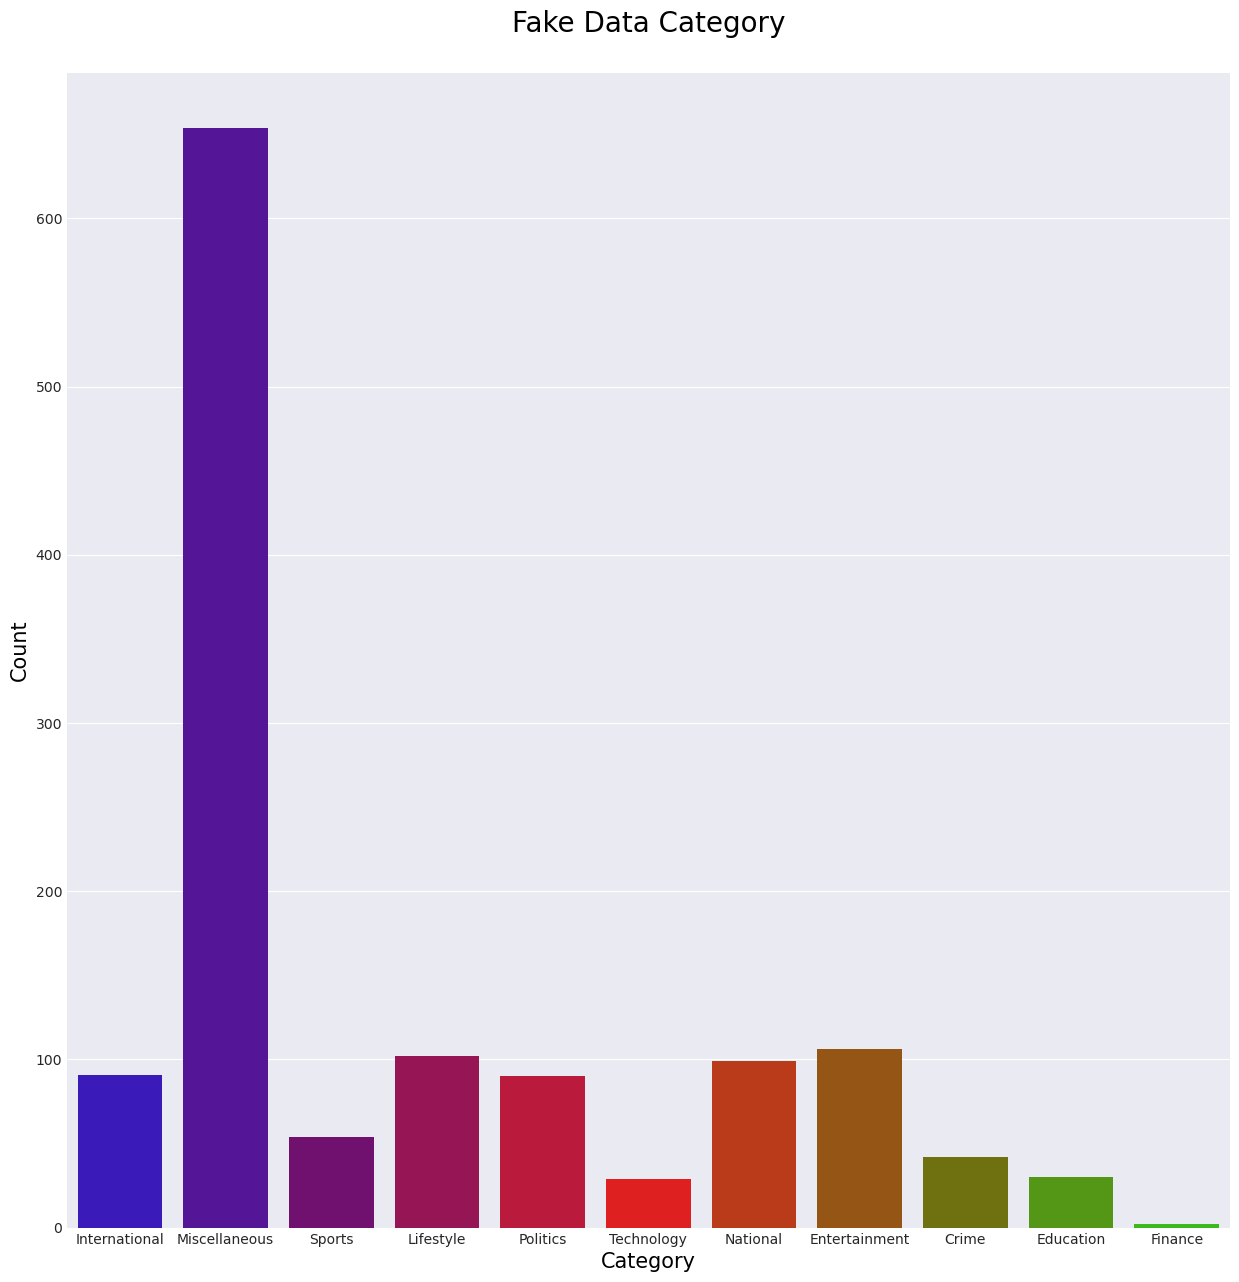

In [17]:
plt.figure(figsize=(15,15))
plt.style.use("seaborn-darkgrid")
sns.countplot(x="category",data=fake_data,palette="brg")
plt.title("Fake Data Category\n",color="black",fontsize=20)
plt.xlabel("Category",fontsize=15,color="black")
plt.ylabel("Count",fontsize=15,color="black")
plt.show()

# Count Real Data Each Category 

In [18]:
real_data["category"].value_counts()

National         18708
International     6990
Sports            6526
Editorial         3504
Politics          2941
Entertainment     2636
Miscellaneous     2218
Finance           1224
Education         1115
Crime             1072
Lifestyle          901
Technology         843
Name: category, dtype: int64

# Real Data Category Visualize

/tmp/ipykernel_6361/1696219580.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-dark-palette")


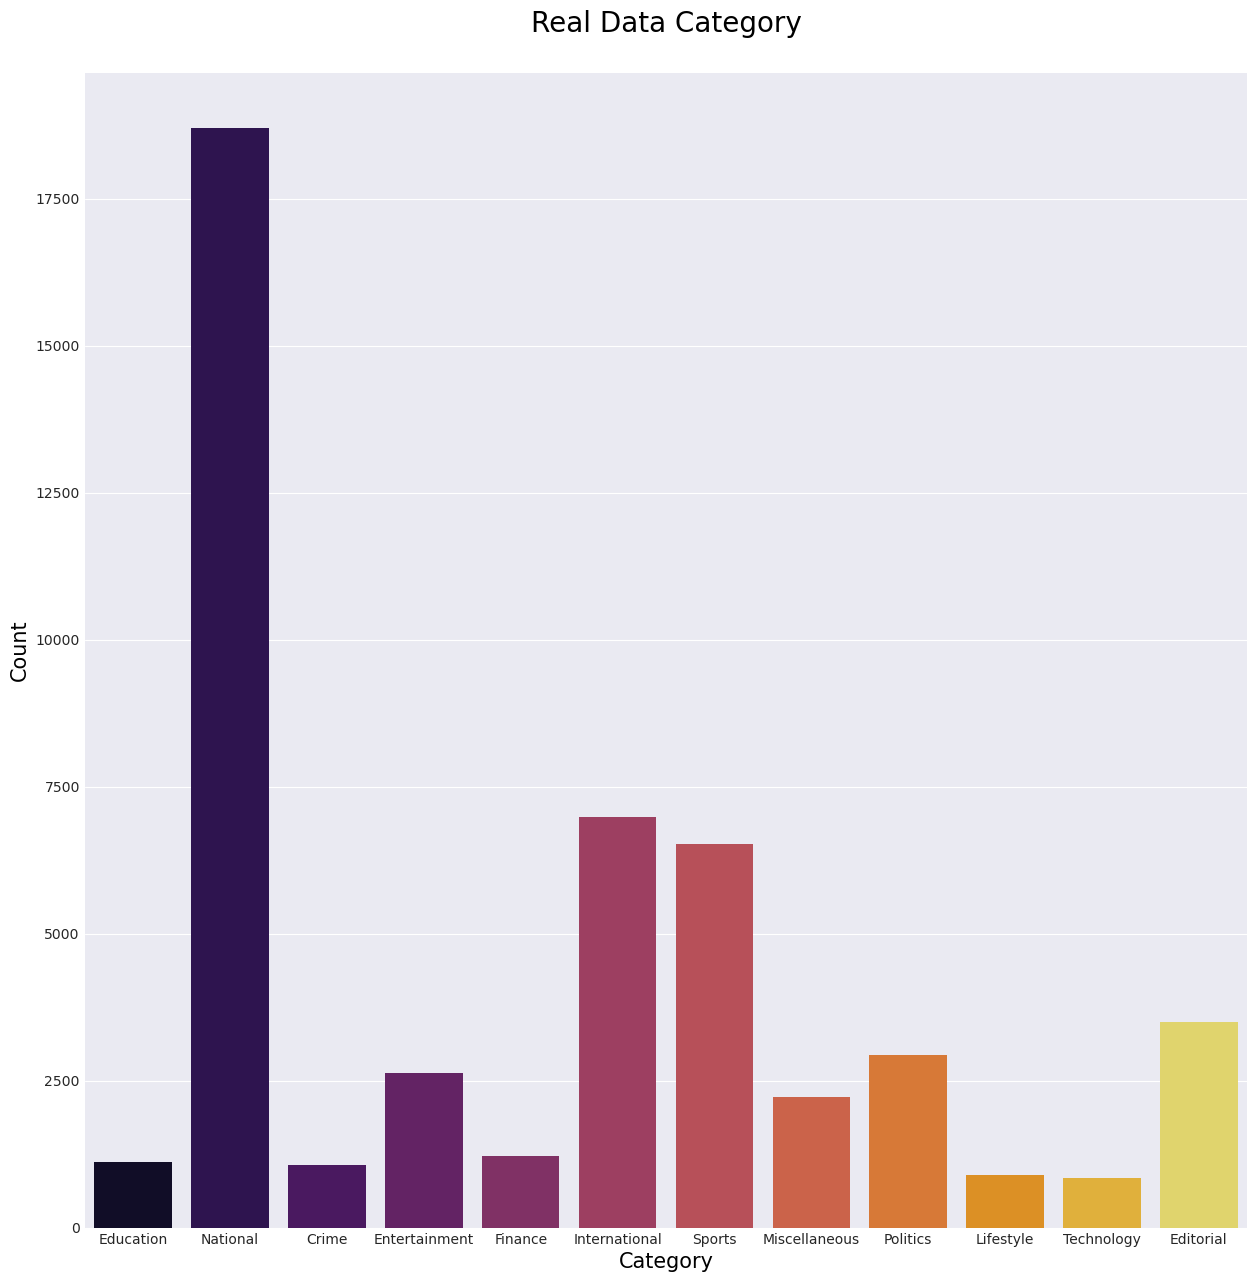

In [19]:
plt.figure(figsize=(15,15))
plt.style.use("seaborn-dark-palette")
sns.countplot(x="category",data=real_data,palette="inferno")
plt.title("Real Data Category\n",color="black",fontsize=20)
plt.xlabel("Category",fontsize=15,color="black")
plt.ylabel("Count",fontsize=15,color="black")
plt.show()

# Drop unnecessary columns

In [20]:
real_data=real_data.drop(["articleID","domain","date","category"],axis=1)

In [21]:
fake_data=fake_data.drop(["articleID","domain","date","category"],axis=1)

In [22]:
real_data.head()

,headline,content,label
0,"হট্টগোল করায় বাকৃবিতে দুইজন বরখাস্ত, ৬ জনকে শোকজ",গত ১৭ সেপ্টেম্বর বাংলাদেশ কৃষি বিশ্ববিদ্যালয়ে ...,1
1,মালয়েশিয়ায় কর্মী পাঠানোর ব্যবস্থা নেয়ার সুপারিশ,বাংলাদেশের বৃহৎ শ্রমবাজার মালয়েশিয়ায় আবার শ্রম...,1
2,প্রেমের প্রস্তাবে রাজি না হওয়ায় স্কুলছাত্রীকে ...,নরসিংদীর মনোহরদীতে প্রেমের প্রস্তাবে রাজি না হ...,1
3,মেডিয়েশনই মামলাজট নিরসনের পথ : বিচারপতি আহমেদ ...,সুপ্রিম কোর্টের হাইকোর্ট বিভাগের বিচারপতি আহমে...,1
4,টকশোতে বক্তব্য দিতে গিয়ে জাপা নেতার মৃত্যু,মাদারীপুর সদরের উপজেলার লেকেরপাড়ে একটি বেসরকার...,1


In [23]:
fake_data.head()

,headline,content,label
0,মুরগির হামলায় শেয়াল নিহত,"বাংলায় একটা প্রবাদ আছে, শেয়ালের কাছে মুরগী বর্...",0
1,বিটিভিতে যেবার আমি ইন্টারভিউ দিতে গেলাম,"BTV থেকে লোকজন আসছে, ইন্টারভিউ নিবে।চারজনের টি...",0
2,বিদেশ থেকে উন্নতমানের বিরোধীদল আমদানি করার পরা...,অদ্ভুত বিরোধীদলহীনতায় ভুগছে সরকার। এ এক অন্যরক...,0
3,অবসর নেয়ার ঘোষণা দিলেন মেসি !,রাশিয়া বিশ্বকাপ নকআউট পর্বে ফ্রান্সের সাথে ৪-৩...,0
4,"মাদারফাকার নহে, ব্রাদারফাকার: সাকা | দৈনিক মতি...","নিজস্ব মতিবেদক‘মাদারফাকার নহে, আমি ব্রাদারফাকা...",0


# Concatenate the Fake Data 'headline' and 'content' columns

In [24]:

fake_data['text'] = fake_data['headline'] + ' ' + fake_data['content']
# Remove the original 'headline' and 'content' columns
fake_data.drop(columns=['headline', 'content'], inplace=True)
fake_data.head()

,label,text
0,0,মুরগির হামলায় শেয়াল নিহত বাংলায় একটা প্রবাদ আছ...
1,0,বিটিভিতে যেবার আমি ইন্টারভিউ দিতে গেলাম BTV থে...
2,0,বিদেশ থেকে উন্নতমানের বিরোধীদল আমদানি করার পরা...
3,0,অবসর নেয়ার ঘোষণা দিলেন মেসি ! রাশিয়া বিশ্বকাপ ...
4,0,"মাদারফাকার নহে, ব্রাদারফাকার: সাকা | দৈনিক মতি..."


# Concatenate the Real Data 'headline' and 'content' Columns

In [25]:

real_data['text'] = real_data['headline'] + ' ' + real_data['content']
# Remove the original 'headline' and 'content' columns
real_data.drop(columns=['headline', 'content'], inplace=True)
real_data.head()

,label,text
0,1,"হট্টগোল করায় বাকৃবিতে দুইজন বরখাস্ত, ৬ জনকে শো..."
1,1,মালয়েশিয়ায় কর্মী পাঠানোর ব্যবস্থা নেয়ার সুপারি...
2,1,প্রেমের প্রস্তাবে রাজি না হওয়ায় স্কুলছাত্রীকে ...
3,1,মেডিয়েশনই মামলাজট নিরসনের পথ : বিচারপতি আহমেদ ...
4,1,টকশোতে বক্তব্য দিতে গিয়ে জাপা নেতার মৃত্যু মাদ...


In [26]:
def clean(text):
    text = re.sub('[%s]' % re.escape(punctuations), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub('\xa0', '', text)
    return text



#  Real Data Wordcloud

In [27]:
# wordcloud_real_text = real_data['text'].apply(lambda x: clean(str(x)))
# wordcloud_text = " ".join(wordcloud_real_text)
# regex = r"[\u0980-\u09FF]+"
# wc = WordCloud(width=1200, height=1200, background_color="black", colormap="plasma", mask=my_image, stopwords=stopwords,
#                font_path=my_font, regexp=regex,max_words=500, random_state=42).generate(wordcloud_text)

# plt.figure(figsize=(15, 15))
# plt.imshow(wc, interpolation='bilinear')
# plt.tight_layout()
# plt.axis("off")
# plt.show()

# Fake Data Wordcloud

In [28]:
# wordcloud_fake_text = fake_data['text'].apply(lambda x: clean(str(x)))
# wordcloud_text_fake = " ".join(wordcloud_fake_text)
# regex = r"[\u0980-\u09FF]+"
# wc = WordCloud(width=1200, height=1200, background_color="lightcyan", colormap="gnuplot", mask=my_image, stopwords=stopwords,
#                font_path=my_font, regexp=regex,max_words=500, random_state=42).generate(wordcloud_text_fake)

# plt.figure(figsize=(15, 15))
# plt.imshow(wc, interpolation='bilinear')
# plt.tight_layout()
# plt.axis("off")
# plt.show()

# Most Common Words In Real Data

In [29]:
# # Load a custom font that supports Bengali characters
# my_font = fm.FontProperties(fname="/kaggle/input/wodcloud-twiter-pic/kalpurush.ttf")

# # Clean the text data
# cleaned_data = real_data['text'].apply(lambda x: clean(str(x)))

# # Split the text into individual words and count their frequency
# top_words = cleaned_data.str.split(expand=True).stack().value_counts().head(30)

# # Create the plot using the custom font
# plt.figure(figsize=(18,18))
# sns.barplot(x=top_words.index, y=top_words.values,palette="tab10")
# plt.title('Top 30 Most Common Words in Real Data', fontproperties=my_font,fontsize=20,color="black")
# plt.xlabel('Word', fontproperties=my_font,fontsize=15,color="black")
# plt.ylabel('Frequency', fontproperties=my_font,fontsize=15,color="black")
# plt.xticks(rotation=90, fontproperties=my_font,fontsize=15,color="navy")
# plt.yticks(fontproperties=my_font,fontsize=15,color="navy")
# plt.show()


In [30]:
# # Clean the text data
# cleaned_data = fake_data['text'].apply(lambda x: clean(str(x)))

# # Split the text into individual words and count their frequency
# top_words = cleaned_data.str.split(expand=True).stack().value_counts().head(30)

# # Create the plot using the custom font
# plt.figure(figsize=(18,18))
# sns.barplot(x=top_words.index, y=top_words.values,palette="tab20")
# plt.title('Top 30 Most Common Words in Fake Data', fontproperties=my_font,fontsize=20,color="black")
# plt.xlabel('Word', fontproperties=my_font,fontsize=15,color="black")
# plt.ylabel('Frequency', fontproperties=my_font,fontsize=15,color="black")
# plt.xticks(rotation=90, fontproperties=my_font,fontsize=15,color="darkred")
# plt.yticks(fontproperties=my_font,fontsize=15,color="darkred")
# plt.show()


# Real Data String Length

In [31]:
# plt.style.use("seaborn-darkgrid")
# # Calculate the text length in characters
# real_data_len= real_data['text'].apply(lambda x: len(x))

# # Create a histogram and a KDE plot of the text length using displot
# sns.displot(real_data_len, kde=True, bins=50,height=8,color="darkorange")
# plt.title("Real Data Length\n",color="darkorange",fontsize=15)
# plt.xlabel('Text length',fontsize=10,color="darkorange")
# plt.ylabel('Count',fontsize=10,color="darkorange")
# plt.show()


# Fake Data Length

In [32]:
# plt.style.use("seaborn-darkgrid")
# # Calculate the text length in characters
# fake_data_len= fake_data['text'].apply(lambda x: len(x))

# # Create a histogram and a KDE plot of the text length using displot
# sns.displot(fake_data_len, kde=True, bins=50,height=8,color="darkgreen")
# plt.title("Fake Data Length\n",color="darkgreen",fontsize=15)
# plt.xlabel('Text length',fontsize=10,color="darkgreen")
# plt.ylabel('Count',fontsize=10,color="darkgreen")
# plt.show()



In [33]:
# real_data_len=real_data["text"].str.len()
# fake_data_len=fake_data["text"].str.len()
# plt.figure(figsize=(10,10))
# plt.hist(real_data_len, bins=100,label='Real_Data_Length',color="navy")
# plt.hist(fake_data_len , bins=100, label='Fake_Data_Length',color="crimson")
# plt.title("Real Data Length Vs Fake Data Length\n",fontsize=15,color="brown")
# plt.legend()
# plt.show()

In [34]:
real_data.head()

,label,text
0,1,"হট্টগোল করায় বাকৃবিতে দুইজন বরখাস্ত, ৬ জনকে শো..."
1,1,মালয়েশিয়ায় কর্মী পাঠানোর ব্যবস্থা নেয়ার সুপারি...
2,1,প্রেমের প্রস্তাবে রাজি না হওয়ায় স্কুলছাত্রীকে ...
3,1,মেডিয়েশনই মামলাজট নিরসনের পথ : বিচারপতি আহমেদ ...
4,1,টকশোতে বক্তব্য দিতে গিয়ে জাপা নেতার মৃত্যু মাদ...


In [35]:
fake_data.head()

,label,text
0,0,মুরগির হামলায় শেয়াল নিহত বাংলায় একটা প্রবাদ আছ...
1,0,বিটিভিতে যেবার আমি ইন্টারভিউ দিতে গেলাম BTV থে...
2,0,বিদেশ থেকে উন্নতমানের বিরোধীদল আমদানি করার পরা...
3,0,অবসর নেয়ার ঘোষণা দিলেন মেসি ! রাশিয়া বিশ্বকাপ ...
4,0,"মাদারফাকার নহে, ব্রাদারফাকার: সাকা | দৈনিক মতি..."


In [36]:
# append the rows of fake_data to real_data and reset the index
append_data = real_data.append(fake_data).reset_index(drop=True)
final_data= append_data.sample(frac=1, random_state=42).reset_index(drop=True)
final_data.head()


/tmp/ipykernel_6361/859812068.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  append_data = real_data.append(fake_data).reset_index(drop=True)


,label,text
0,1,‘সাংবাদিকতাকে সাহিত্যে উত্তীর্ণ করেছিলেন গোলাম...
1,1,নেইমারের দুর্দান্ত হ্যাটট্রিকে পিএসজির বিশাল জ...
2,1,ডিজিটাল নিরাপত্তা আইন নিয়ে যা বললেন জয় জাতীয়...
3,1,দেশ দখলের ঘোষণার প্রতিবাদ প্রধানমন্ত্রী করলেন ...
4,1,শিশুদের ক্যানভাসে প্রধানমন্ত্রীর জন্মদিন নানা ...


In [37]:
# plt.figure(figsize=(8,8))
# sns.countplot(x="label",data=final_data,palette="hsv")
# plt.title("Label Count",fontsize=15,color="black")
# plt.xlabel("Label",fontsize=12,color="black")
# plt.ylabel("Count",fontsize=12,color="black")
# xticklabels = ["Fake", "Real"]
# plt.xticks(ticks=[0, 1], labels=xticklabels,fontsize=12,color="brown")

# plt.show()

In [38]:

# def remove_html_tags(text):
#     return BeautifulSoup(text, 'html.parser').get_text()

# def remove_punctuation(text):
#     text = ''.join([c for c in text if c not in string.punctuation])
#     return text

# def remove_extra_whitespace_tabs(text):
#     pattern = r'^\s*|\s\s*'
#     return re.sub(pattern, ' ', text).strip()

# def bn_lemmatization(text):
    
#     return bn.stemmer(text)

# def remove_bn_stopwords(text):
#     final_text = []
#     for word in text.split():
#         if word not in nltk_stopwords.words('bengali'):
#             final_text.append(word)
#     return " ".join(final_text)

# def remove_bangla_digits(text):
#     bn_digits = ["০", "১", "২", "৩", "৪", "৫", "৬", "৭", "৮", "৯"]
#     for d in bn_digits:
#         text = text.replace(d, "")
#     return text

# def remove_emojis(text):
#     text = emoji.get_emoji_regexp().sub(u'', text)
#     return text

# def cleaning(text):
#     text = remove_html_tags(text)
#     text = remove_bn_stopwords(text)
#     text = remove_punctuation(text)
#     text = remove_extra_whitespace_tabs(text)
#     text = bn_lemmatization(text)
#     text = remove_bangla_digits(text)
#     text = remove_emojis(text)
#     return text


In [39]:
with open('/kaggle/input/wodcloud-twiter-pic/stopwords-bn.txt', 'r', encoding='utf-8-sig') as f:
    stop_word = f.read()
    stop_word = stop_word.replace(" ", "")
    stop_word = stop_word.split('\n')
    print(stop_word)

['অতএব', 'অথচ', 'অথবা', 'অনুযায়ী', 'অনেক', 'অনেকে', 'অনেকেই', 'অন্তত', 'অন্য', 'অবধি', 'অবশ্য', 'অর্থাত', 'আই', 'আগামী', 'আগে', 'আগেই', 'আছে', 'আজ', 'আদ্যভাগে', 'আপনার', 'আপনি', 'আবার', 'আমরা', 'আমাকে', 'আমাদের', 'আমার', 'আমি', 'আর', 'আরও', 'ই', 'ইত্যাদি', 'ইহা', 'উচিত', 'উত্তর', 'উনি', 'উপর', 'উপরে', 'এ', 'এঁদের', 'এঁরা', 'এই', 'একই', 'একটি', 'একবার', 'একে', 'এক্', 'এখন', 'এখনও', 'এখানে', 'এখানেই', 'এটা', 'এটাই', 'এটি', 'এত', 'এতটাই', 'এতে', 'এদের', 'এব', 'এবং', 'এবার', 'এমন', 'এমনকী', 'এমনি', 'এর', 'এরা', 'এল', 'এস', 'এসে', 'ঐ', 'ও', 'ওঁদের', 'ওঁর', 'ওঁরা', 'ওই', 'ওকে', 'ওখানে', 'ওদের', 'ওর', 'ওরা', 'কখনও', 'কত', 'কবে', 'কমনে', 'কয়েক', 'কয়েকটি', 'করছে', 'করছেন', 'করতে', 'করবে', 'করবেন', 'করলে', 'করলেন', 'করা', 'করাই', 'করায়', 'করার', 'করি', 'করিতে', 'করিয়া', 'করিয়ে', 'করে', 'করেই', 'করেছিলেন', 'করেছে', 'করেছেন', 'করেন', 'কাউকে', 'কাছ', 'কাছে', 'কাজ', 'কাজে', 'কারও', 'কারণ', 'কি', 'কিংবা', 'কিছু', 'কিছুই', 'কিন্তু', 'কী', 'কে', 'কেউ', 'কেউই', 'কেখা', 'কেন', 'কোটি', 'কোন', 'কোনও'

In [40]:
final_data.head()

,label,text
0,1,‘সাংবাদিকতাকে সাহিত্যে উত্তীর্ণ করেছিলেন গোলাম...
1,1,নেইমারের দুর্দান্ত হ্যাটট্রিকে পিএসজির বিশাল জ...
2,1,ডিজিটাল নিরাপত্তা আইন নিয়ে যা বললেন জয় জাতীয়...
3,1,দেশ দখলের ঘোষণার প্রতিবাদ প্রধানমন্ত্রী করলেন ...
4,1,শিশুদের ক্যানভাসে প্রধানমন্ত্রীর জন্মদিন নানা ...


In [41]:
final_data['num_characters'] = final_data['text'].apply(len)

In [42]:
final_data['num_words'] = final_data['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [43]:
final_data['num_sentences'] = final_data['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [44]:
final_data[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,49977.000000,49977.000000,49977.000000
mean,1856.877924,302.737179,2.291994
std,1496.867842,250.824343,3.511740
min,10.000000,2.000000,1.000000
25%,978.000000,157.000000,1.000000
50%,1437.000000,232.000000,1.000000
75%,2190.000000,357.000000,2.000000
max,27177.000000,5148.000000,206.000000


In [45]:
final_data[final_data['label']==0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1299.000000,1299.000000,1299.000000
mean,1816.732871,313.480370,3.857583
std,1250.770523,220.037646,4.433262
min,84.000000,16.000000,1.000000
25%,1034.000000,176.000000,1.000000
50%,1523.000000,262.000000,2.000000
75%,2221.000000,387.000000,4.000000
max,17771.000000,3058.000000,55.000000


In [46]:
final_data[final_data['label']==1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,48678.000000,48678.000000,48678.000000
mean,1857.949217,302.450491,2.250216
std,1502.879272,251.590010,3.474217
min,10.000000,2.000000,1.000000
25%,978.000000,157.000000,1.000000
50%,1434.000000,231.000000,1.000000
75%,2190.000000,356.000000,2.000000
max,27177.000000,5148.000000,206.000000


In [47]:
# plt.figure(figsize=(10,10))
# sns.histplot(final_data[final_data['label']==1]['num_characters'], color='blue')
# sns.histplot(final_data[final_data['label']==0]['num_characters'],color="yellow")
# plt.show()

In [48]:
# plt.figure(figsize=(10,10))
# sns.histplot(final_data[final_data['label']==1]['num_words'], color='orange')
# sns.histplot(final_data[final_data['label']==0]['num_words'],color="green")
# plt.show()


In [49]:
# plt.figure(figsize=(10,10))
# sns.histplot(final_data[final_data['label']==1]['num_sentences'], color='purple',bins=100)
# sns.histplot(final_data[final_data['label']==0]['num_sentences'],color="gold",bins=100)
# plt.show()

In [50]:
# plt.figure(figsize=(10,10))
# my_color=["red","green"]
# my_marker=["D","P"]
# sns.pairplot(final_data,hue="label",palette=my_color,height=3,markers=my_marker,plot_kws={"s":100})
# plt.show()

In [51]:
final_data=final_data.drop(["num_characters","num_words","num_sentences"],axis=1)

In [52]:
def clean_text(text):
    row = str(text)
    row = row.replace('\n', ' ')
    row = row.replace('\t', ' ')
    row = row.replace('\\', "")
    row = re.sub('[!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]', '', row)
    row = re.sub(' +', ' ', row)
    row = row.replace("।", "")
    row = re.sub('[১২৩৪৫৬৭৮৯০]', '', row)
    row = re.sub('[1234567890]', '', row) 
    row = row.replace('’', '')
    row = row.replace('‘', '')
    
    # Removing stop words
    row = row.split()
    row = [w for w in row if not w in stop_word]
    row = " ".join(row)
    return row

In [53]:
final_data['text'] = final_data['text'].apply(clean_text)

In [54]:
final_data.head()

,label,text
0,1,সাংবাদিকতাকে সাহিত্যে উত্তীর্ণ গোলাম সারওয়ার স...
1,1,নেইমারের দুর্দান্ত হ্যাটট্রিকে পিএসজির বিশাল জ...
2,1,ডিজিটাল নিরাপত্তা আইন জয় জাতীয় সংসদে সদ্য পাস...
3,1,দেশ দখলের ঘোষণার প্রতিবাদ প্রধানমন্ত্রী অক্টোব...
4,1,শিশুদের ক্যানভাসে প্রধানমন্ত্রীর জন্মদিন রঙের ...


In [55]:
avg=final_data['text'].apply(len)
avg_len=avg.mean()
print(f"Average Text Length: {avg_len}")

Average Text Length: 1464.8318826660263


In [56]:
max_len=300
my_label=final_data["label"].values
my_text=final_data["text"].values


In [57]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(my_text)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1


In [58]:
# embedding_file = '/kaggle/input/global-vectorglove/glove.840B.300d.txt'
# embedding_dim = 300

# embedding_index = {}
# with open(embedding_file, encoding='utf-8') as f:
#     reader = csv.reader(f, delimiter=' ', quoting=csv.QUOTE_NONE)
#     for row in reader:
#         word = row[0]
#         coefs = np.asarray(row[1:], dtype='float32')
#         embedding_index[word] = coefs
        

# # Create embedding matrix
# embedding_matrix = np.zeros((vocab_size, embedding_dim))
# for word, i in word_index.items():
#     embedding_vector = embedding_index.get(word)
#     if embedding_vector is not None:
#         embedding_matrix[i] = embedding_vector

In [59]:
# tokenizer.word_index.items()

In [60]:
from tqdm import tqdm

embedding_vector = {}
f = open('/kaggle/input/global-vectorglove/glove.840B.300d.txt')
for line in tqdm(f):
    value = line.split(' ')
    word = value[0]
    coef = np.array(value[1:],dtype = 'float32')
    embedding_vector[word] = coef
    


2196017it [03:24, 10742.51it/s]


In [61]:
embedding_matrix = np.zeros((vocab_size,300))
for word,i in tqdm(tokenizer.word_index.items()):
    embedding_value = embedding_vector.get(word)
    if embedding_value is not None:
        embedding_matrix[i] = embedding_value

100%|██████████| 281988/281988 [00:00<00:00, 902293.45it/s]


In [62]:
sequences = tokenizer.texts_to_sequences(my_text)
padded_sequences = pad_sequences(sequences, maxlen=max_len)

In [63]:
X_train,X_test,Y_train,Y_test = train_test_split(padded_sequences,my_label,test_size=0.2,random_state=42)

In [64]:

embedding_dim=300
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,weights=[embedding_matrix],input_length=max_len))
model.add(LSTM(units=128, activation="tanh"))
model.add(Dropout(0.3))
model.add(Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 300, 300)          84596700  
                                                                 
 lstm (LSTM)                 (None, 128)               219648    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 84,816,477
Trainable params: 84,816,477
Non-trainable params: 0
_________________________________________________________________


In [65]:
history=model.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=10,batch_size=64)

Epoch 1/10
625/625 [==============================] - 119s 185ms/step - loss: 0.0791 - accuracy: 0.9789 - val_loss: 0.0524 - val_accuracy: 0.9848
Epoch 2/10
625/625 [==============================] - 71s 114ms/step - loss: 0.0138 - accuracy: 0.9962 - val_loss: 0.0462 - val_accuracy: 0.9853
Epoch 3/10
625/625 [==============================] - 51s 82ms/step - loss: 0.0021 - accuracy: 0.9997 - val_loss: 0.0632 - val_accuracy: 0.9883
Epoch 4/10
625/625 [==============================] - 34s 55ms/step - loss: 6.0132e-04 - accuracy: 0.9998 - val_loss: 0.0582 - val_accuracy: 0.9882
Epoch 5/10
625/625 [==============================] - 31s 49ms/step - loss: 3.6854e-04 - accuracy: 0.9999 - val_loss: 0.0742 - val_accuracy: 0.9892
Epoch 6/10
625/625 [==============================] - 29s 46ms/step - loss: 2.2571e-04 - accuracy: 0.9999 - val_loss: 0.0830 - val_accuracy: 0.9887
Epoch 7/10
625/625 [==============================] - 26s 41ms/step - loss: 9.6092e-05 - accuracy: 1.0000 - val_loss: 0.0

# Model Loss And Accuracy Graph

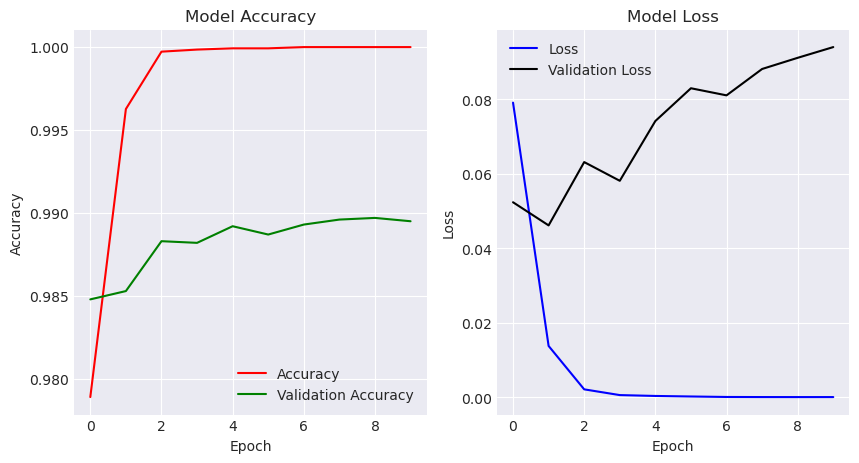

In [66]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# First subplot
ax[0].plot(history.history['accuracy'],label="Accuracy",color="red")
ax[0].plot(history.history['val_accuracy'],label="Validation Accuracy",color="green")
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='best')

# Second subplot
ax[1].plot(history.history['loss'],label="Loss",color="blue")
ax[1].plot(history.history['val_loss'],label="Validation Loss",color="black")
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='best')

plt.show()


# Model Predict

In [67]:
pred=model.predict(X_test)
final_predict=(pred>=0.5).astype("int32")

313/313 [==============================] - 3s 8ms/step


# receiver operating characteristic curve 

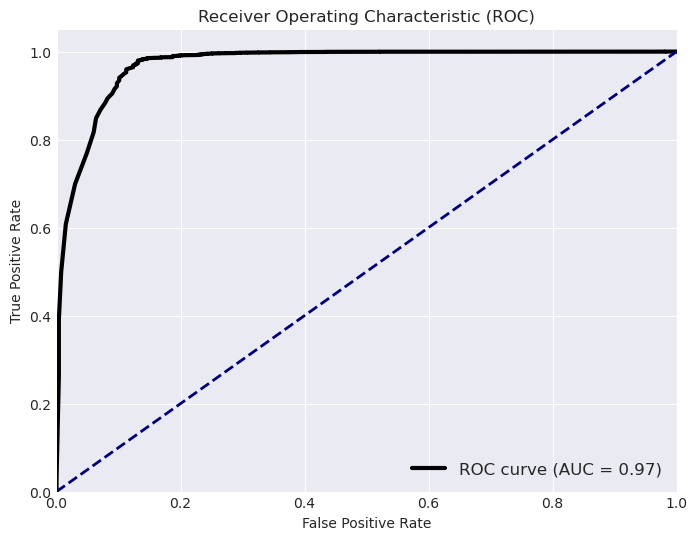

In [68]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(Y_test,pred)
# Calculating the area under the ROC curve (AUC)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='black', lw=3, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right",fontsize=12,edgecolor="black")
plt.show()


# Precision Recall Curve

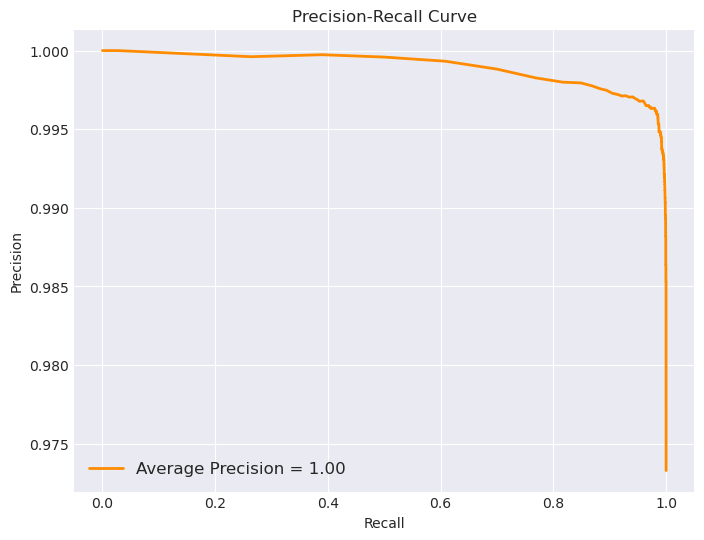

In [69]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# Calculating precision and recall values
precision, recall, thresholds = precision_recall_curve(Y_test,pred)
# Calculating the average precision (AP) score
ap_score = average_precision_score(Y_test,pred)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, label='Average Precision = %0.2f' % ap_score)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left",fontsize=12,edgecolor="black")
plt.show()


#  Confusion Matrix

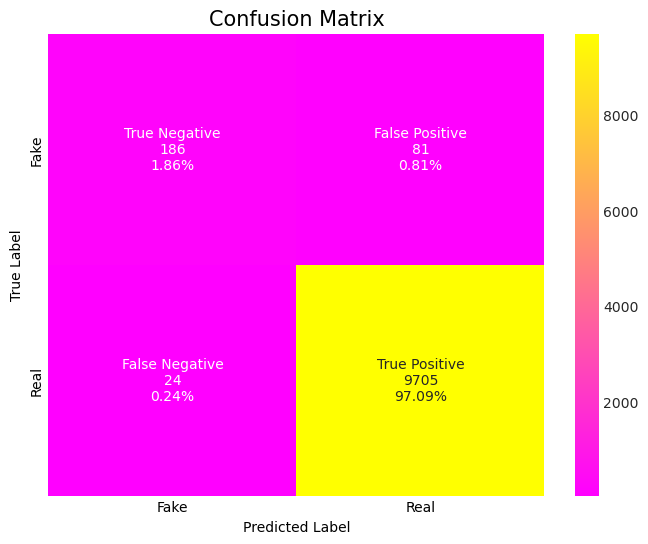

In [70]:
label_name=["Fake","Real"]
my_matrix= confusion_matrix(Y_test, final_predict)
my_label = ["True Negative","False Positive","False Negative","True Positive"]
my_label_count=["{0:0.0f}".format(value) for value in my_matrix.flatten()]
percentage=["{0:.2%}".format(value) for value in my_matrix.flatten()/np.sum(my_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(my_label,my_label_count,percentage)]
labels=np.asarray(labels).reshape(2, 2)
# Plot confusion matrix as heatmap using Seaborn
plt.figure(figsize=(8,6))
sns.heatmap(my_matrix, annot=labels, cmap="spring", fmt="", cbar=True,
            xticklabels=label_name,yticklabels=label_name)
plt.xlabel("Predicted Label",fontsize=10,color="black")
plt.ylabel("True Label",fontsize=10,color="black")
plt.title("Confusion Matrix",fontsize=15,color="black")
plt.xticks(fontsize=10,color="black")
plt.yticks(fontsize=10,color="black")
plt.show()

# Classification Report

In [71]:
print(classification_report(Y_test,final_predict,target_names=label_name))

              precision    recall  f1-score   support

        Fake       0.89      0.70      0.78       267
        Real       0.99      1.00      0.99      9729

    accuracy                           0.99      9996
   macro avg       0.94      0.85      0.89      9996
weighted avg       0.99      0.99      0.99      9996



# Precision Score

In [72]:
from sklearn.metrics import precision_score

# Calculating precision score
precision = precision_score(Y_test,final_predict)

# Printing the precision score
print('Precision: %.4f' % precision)

Precision: 0.9917


# Kappa Score

In [73]:
from sklearn.metrics import cohen_kappa_score

# Calculating the Cohen's kappa score
kappa_score = cohen_kappa_score(Y_test,final_predict)

# Printing the kappa score
print('Cohen\'s Kappa Score: %.4f' % kappa_score)


Cohen's Kappa Score: 0.7746


# Roc Auc Score

In [74]:
from sklearn.metrics import roc_auc_score

# Calculating the ROC AUC score
roc_auc = roc_auc_score(Y_test,pred)

# Printing the ROC AUC score
print('ROC AUC Score: %.4f' % roc_auc)


ROC AUC Score: 0.9712


# Matthews Correlation Coefficient 

In [75]:
from sklearn.metrics import matthews_corrcoef

# Calculating the MCC
mcc = matthews_corrcoef(Y_test,final_predict)

# Printing the MCC
print('MCC Score: %.4f' % mcc)


MCC Score: 0.7804


# Logarithmic Loss

In [76]:
from sklearn.metrics import log_loss

# Calculating the logarithmic loss
log_loss_score = log_loss(Y_test,final_predict)

# Printing the logarithmic loss
print('Logarithmic Loss: %.4f' % log_loss_score)


Logarithmic Loss: 0.3786


In [77]:
from sklearn.metrics import brier_score_loss


# Calculating the Brier score
brier_score = brier_score_loss(Y_test,final_predict)

# Printing the Brier score
print('Brier Score: %.3f' % brier_score)


Brier Score: 0.011


In [78]:
x=["জার্সি বদলের নির্বাচন নির্বাচন সাজ সাজ রব অনেকদিন চাখানায় প্রাণ ফিরেছে ভোটারদের মাঝে তালগাছপুরের মালিক ভাবখানা এসেছে ভোট প্রার্থীরা বিগলিত হাসি দিয়ে কাঁচুমাঁচু মুখ ভোট চেয়ে বেড়াচ্ছে ভোটের মিডলম্যানরা টাকার বান্ডিল ইউনিয়নের ভোট কিনবে দামদস্তুর মিডলম্যানকে প্রফিট মার্জিন রেখেই পাইকারী দরে এক ইউনিয়নের ভোট কেনার ফন্দিফিকির আঁটতে অনেকদিন ভোট ভোট হয়না ভোটহীন নির্বাচন কালচার শুকিয়ে মারার অবস্থা হয়েছিলো ভোট ক্রেতা মিডলম্যানরা একটু মোটা মুনাফা চাইছে ভোটাররা এমনিতেই মার্কার রাখতে আজগুবি কাণ্ড ঘটেছে নৌকা মার্কা ভোট লোক এসেছে ধানের শীষ মার্কা ধানের শীষ মার্কা ভোট লোক এসেছে নৌকা মার্কা ভোটারদের ব্যাপক কনফিউশান তৈরি হয়েছে প্রবীনেরা পড়েছেন বিরাট ধন্দে এক অশীতিপর বৃদ্ধ চায়ের দোকানে মাটিতে লাটি দিয়ে ঘন ঘন চাপ কেঁপে কেঁপে ভোট খেলায় দেখতেছি ফুটবল খেলার জার্সি বদল গতবার সাফারি সানগ্লাস চোখে ঘুরতে দেখলাম কালো ফ্রেমের চশমা চোখে মুজিব কোট ঘুরছে গতবারের মুজিব কোট পরা প্রার্থী সাফারি সানগ্লাস চোখে লাগিয়ে ঘুরছে মাথাডা ঘুরান্তি দিতেছে বাবারা সাইকেল থামিয়ে চাখানার আড্ডায় কানপাতা এক তরুণ ফোড়ন কাটে উনাদের খরচ বাইচা চাচা শুনলাম প্রার্থীরা মাঝে মার্কা বিনিময়ের মহরতে ড্রেস বিনিময় এক লোক টিটকারি দিয়ে এক প্রার্থীর গায়ের সাফারি দেইখা ঐজন্যই বুঝি একটু টাইট হইলো সবাই সমস্বরে হেসে ওঠে এসময় প্রার্থী নৌকা ভাইয়া উপস্থিত করমর্দন দোয়া এরপর নৌকা ভাইয়া ওপর ভরসা রাখুন খবরদার ধানের শীষে ভোট দিবেন দেশটা পাকিস্তান হয়ে চারিদিকে বোমার শব্দ শুনতে চাখানার মালিক ভাই গতবার ধানের শীষ মার্কা নিয়া আসছিলেন বলছিলেন নৌকায় ভোট দিলে দেশটা ভারত হয়ে মসজিদে উলু শোনা নৌকা ভাইয়া বিব্রত ঢোক গিলে অতীতের ভুল মানুষ শেখে আছিলাম বোকা হইলাম বুদ্ধিমান সবাইকে সালাম দিয়ে নৌকা ভাইয়া প্রচারণায় এগিয়ে অনুসরণ প্রার্থী ধানের শীষ ভাই উপস্থিত কুশল বিনিময় টাইট সাফারি মুচকি হাসি বিনিময় ধানের শীষ ভাইয়া ওপর আস্থা রাখুন খবরদার নৌকায় ভোট দেবেন দেশটা ভারত হয়ে মসজিদে উলু শুনতে উপস্থিত একজন ভাই গতবার নৌকা মার্কা নিয়া আসছিলেন ধানের শীষে ভোট নিষেধ করছিলেন বলছিলেন দেশটা পাকিস্তান হইয়া যাইবো সারা দেশে বোমার শব্দ শোনা অশীতিপর বৃদ্ধ আচ্ছা বাবা তোমাদের পলিটিকস যাত্রাপালা তোমরা প্রার্থী রোলে আইসা পোষাক বদলাইছো একজন হুবহু আরেকজনের গতবারের ডায়ালগ দিতেছো ধানের শীষ ভাইয়া কাতর হেসে কোনমতে বিদায় প্রচারণায় এগিয়ে নৌকা ভাইয়ার সমর্থকরা ভাইজান ধানের শীষের প্রচারণায় বাধা হইবো আপনে দেখি কন ফোন দিয়া ওসি সাহেবরে ডাকি নৌকা ভাইয়া একটু আনমনা হয়ে ধানের শীষের প্রচারণায় লোকগুলো গতবার তারই কর্মী ছিলো বিড়বিড় থাক ঝামেলায় যাওয়ার দরকার মন দিয়া প্রচারণা চালাও ধানের শীষ ভাইয়ার সমর্থকরা ফুসলায় এইখানে নৌকার প্রার্থী নরম হইতেছে যাই নৌকার প্রচারণায় বাধা দিই ভাইয়া ওসিরে একটু মোটা অংকের ভালবাসা দিয়া ব্যাপারটা ম্যানেজ ধানের শীষ ভাইয়া আনমনা হয়ে ভাবতে নৌকার কর্মীরা গতবার তারই কর্মী ছিলো স্বগতোক্তির মত থাক মন দিয়া প্রচারণা চালাও নৌকা ভাইয়া হাত নেড়ে একজনকে চাচা মার্কাডা ভোটটা দিয়েন গো চাচা চাচা খুক খুক কাশতে কাশতে বাজান ধানের শীষে ভোটটা ঠিকই দিমু নৌকা ভাইয়ার মাথায় বাজ ভেঙ্গে পড়ে ওদিকে ধানের শীষ ভাইয়া রিক্সায় এক ভোটারকে সালাম দিয়ে মুরুব্বি মার্কাডা নিশ্চয়ই আপনারে ভোট চাচা খিলখিল হেসে নৌকা নৌকায় ভোট দিমু ধানের শীষ ভাইয়া হতাশ হয়ে এক দোকানের বেঞ্চে পড়েন"]
my_text_seq=tokenizer.texts_to_sequences(x)
my_text=pad_sequences(my_text_seq,maxlen=max_len)
my_pred=model.predict(my_text)
myfinal_pred=(my_pred>=0.5).astype("int32")

if myfinal_pred==0:
    print("News is Fake")
else:
    print("News is Real")

1/1 [==============================] - 0s 23ms/step
News is Fake


# LSTM+ONEHOT+GLOVE

In [79]:
final_data.head()

,label,text
0,1,সাংবাদিকতাকে সাহিত্যে উত্তীর্ণ গোলাম সারওয়ার স...
1,1,নেইমারের দুর্দান্ত হ্যাটট্রিকে পিএসজির বিশাল জ...
2,1,ডিজিটাল নিরাপত্তা আইন জয় জাতীয় সংসদে সদ্য পাস...
3,1,দেশ দখলের ঘোষণার প্রতিবাদ প্রধানমন্ত্রী অক্টোব...
4,1,শিশুদের ক্যানভাসে প্রধানমন্ত্রীর জন্মদিন রঙের ...


In [80]:
texts = final_data['text']
# Convert text column to one-hot encoded representations
one_hot_texts = [one_hot(text,vocab_size) for text in texts]
# Replace the original text column with the one-hot encoded representations
final_data['text'] = one_hot_texts
# Print the updated final_data DataFrame
print(final_data.head())

   label                                               text
0      1  [9040, 9741, 242628, 139422, 209431, 191718, 2...
1      1  [91056, 99399, 194570, 89508, 33266, 121215, 4...
2      1  [142966, 178254, 90377, 130259, 4264, 112250, ...
3      1  [135054, 96858, 163018, 248639, 147381, 246632...
4      1  [246551, 174342, 226031, 148922, 162316, 23840...


In [81]:
my_onehot_data=final_data["text"]
embedded_doc=pad_sequences(my_onehot_data,padding='pre',maxlen=max_len)
embedded_doc

array([[     0,      0,      0, ..., 181956, 267765, 113970],
       [     0,      0,      0, ..., 269703, 135735, 100455],
       [ 88500, 200285, 259336, ..., 233841, 258743, 175936],
       ...,
       [ 66915, 216221, 227814, ..., 264348, 246632, 212548],
       [  6966, 150440, 222125, ..., 129667,  14009,  77046],
       [     0,      0,      0, ...,  71009,  92409, 255365]], dtype=int32)

In [82]:
text_data=np.array(embedded_doc)
y=final_data["label"]
label_data2=np.array(y)

In [83]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(text_data,label_data2, test_size=0.2, random_state=42)

In [84]:
model2 = Sequential()
model2.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,weights=[embedding_matrix],input_length=max_len))
model2.add(LSTM(units=128, activation="tanh"))
model2.add(Dropout(0.3))
model2.add(Dense(units=1, activation='sigmoid'))
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 300, 300)          84596700  
                                                                 
 lstm_1 (LSTM)               (None, 128)               219648    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 84,816,477
Trainable params: 84,816,477
Non-trainable params: 0
_________________________________________________________________


In [85]:
history2 = model2.fit(X_train2, Y_train2, validation_data=(X_test2, Y_test2), epochs=10, batch_size=64)

Epoch 1/10
625/625 [==============================] - 92s 143ms/step - loss: 0.0815 - accuracy: 0.9790 - val_loss: 0.0472 - val_accuracy: 0.9869
Epoch 2/10
625/625 [==============================] - 53s 85ms/step - loss: 0.0162 - accuracy: 0.9956 - val_loss: 0.0525 - val_accuracy: 0.9872
Epoch 3/10
625/625 [==============================] - 39s 63ms/step - loss: 0.0029 - accuracy: 0.9992 - val_loss: 0.0506 - val_accuracy: 0.9858
Epoch 4/10
625/625 [==============================] - 33s 52ms/step - loss: 8.0661e-04 - accuracy: 0.9998 - val_loss: 0.0782 - val_accuracy: 0.9884
Epoch 5/10
625/625 [==============================] - 27s 43ms/step - loss: 2.7809e-04 - accuracy: 0.9999 - val_loss: 0.0767 - val_accuracy: 0.9873
Epoch 6/10
625/625 [==============================] - 28s 44ms/step - loss: 6.1262e-04 - accuracy: 0.9998 - val_loss: 0.0749 - val_accuracy: 0.9889
Epoch 7/10
625/625 [==============================] - 26s 42ms/step - loss: 2.2187e-04 - accuracy: 0.9999 - val_loss: 0.097

# Model2 Loss And Accuracy Graph

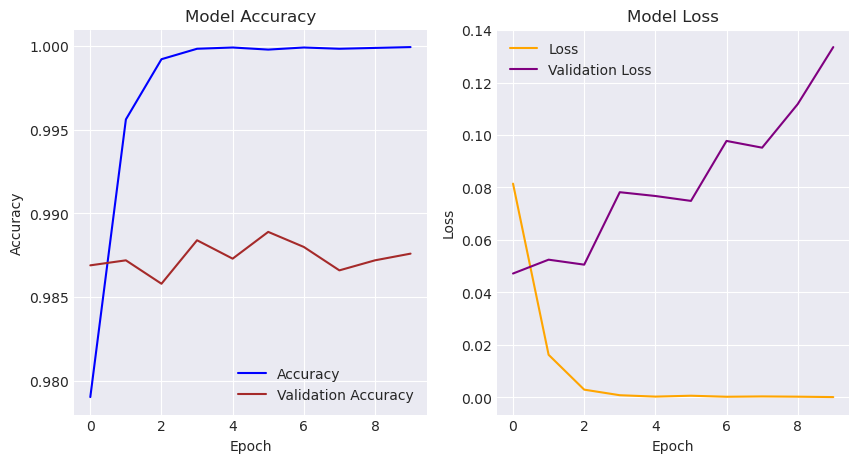

In [86]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# First subplot
ax[0].plot(history2.history['accuracy'],label="Accuracy",color="blue")
ax[0].plot(history2.history['val_accuracy'],label="Validation Accuracy",color="brown")
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='best')

# Second subplot
ax[1].plot(history2.history['loss'],label="Loss",color="orange")
ax[1].plot(history2.history['val_loss'],label="Validation Loss",color="purple")
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='best')

plt.show()


In [87]:
pred2=model2.predict(X_test2)
final_predict2=(pred>=0.5).astype("int32")

313/313 [==============================] - 3s 7ms/step


# Receiver Operating Characteristic Curve

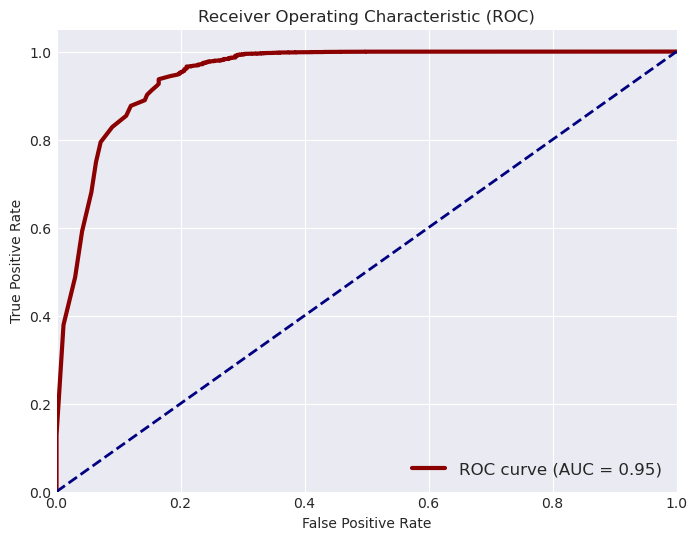

In [88]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(Y_test,pred2)
# Calculating the area under the ROC curve (AUC)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkred', lw=3, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right",fontsize=12,edgecolor="black")
plt.show()


# Precision Recall Curve

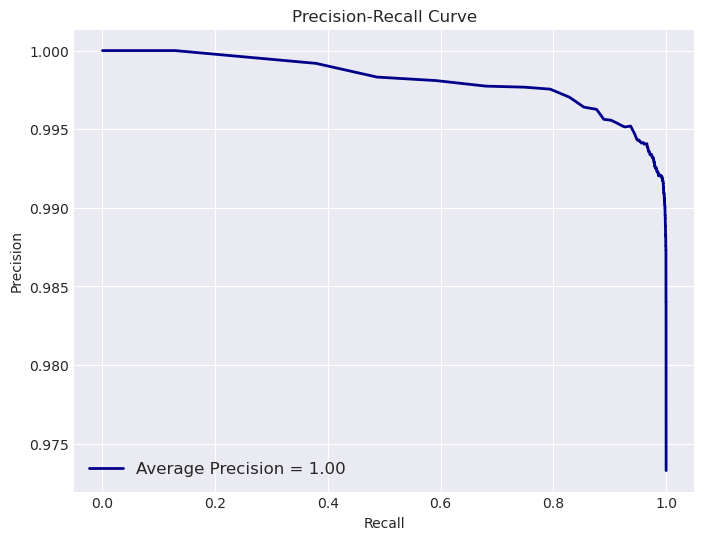

In [89]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# Calculating precision and recall values
precision, recall, thresholds = precision_recall_curve(Y_test,pred2)
# Calculating the average precision (AP) score
ap_score = average_precision_score(Y_test,pred)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkblue', lw=2, label='Average Precision = %0.2f' % ap_score)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left",fontsize=12,edgecolor="black")
plt.show()

# Confusion Matrix

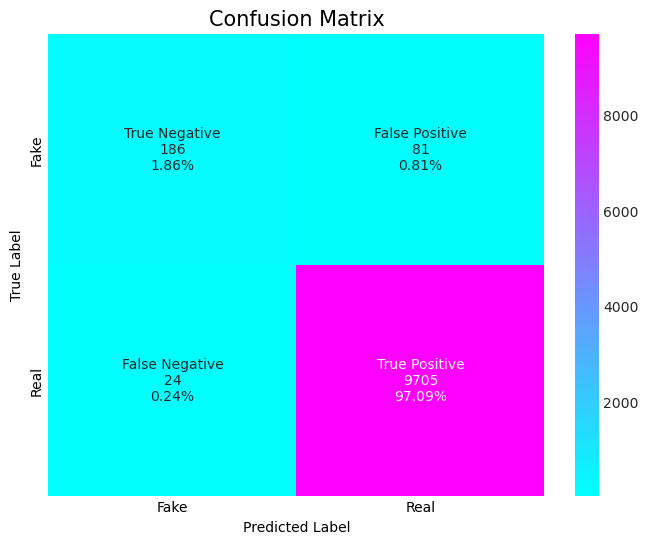

In [90]:
label_name=["Fake","Real"]
my_matrix= confusion_matrix(Y_test, final_predict2)
my_label = ["True Negative","False Positive","False Negative","True Positive"]
my_label_count=["{0:0.0f}".format(value) for value in my_matrix.flatten()]
percentage=["{0:.2%}".format(value) for value in my_matrix.flatten()/np.sum(my_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(my_label,my_label_count,percentage)]
labels=np.asarray(labels).reshape(2, 2)
# Plot confusion matrix as heatmap using Seaborn
plt.figure(figsize=(8,6))
sns.heatmap(my_matrix, annot=labels, cmap="cool", fmt="", cbar=True,
            xticklabels=label_name,yticklabels=label_name)
plt.xlabel("Predicted Label",fontsize=10,color="black")
plt.ylabel("True Label",fontsize=10,color="black")
plt.title("Confusion Matrix",fontsize=15,color="black")
plt.xticks(fontsize=10,color="black")
plt.yticks(fontsize=10,color="black")
plt.show()

# Classification Report

In [91]:
print(classification_report(Y_test,final_predict2,target_names=label_name))

              precision    recall  f1-score   support

        Fake       0.89      0.70      0.78       267
        Real       0.99      1.00      0.99      9729

    accuracy                           0.99      9996
   macro avg       0.94      0.85      0.89      9996
weighted avg       0.99      0.99      0.99      9996



# Kappa score

In [92]:
from sklearn.metrics import cohen_kappa_score

# Calculating the Cohen's kappa score
kappa_score = cohen_kappa_score(Y_test,final_predict2)

# Printing the kappa score
print('Cohen\'s Kappa Score: %.4f' % kappa_score)

Cohen's Kappa Score: 0.7746


# Roc Auc Score

In [93]:
from sklearn.metrics import roc_auc_score

# Calculating the ROC AUC score
roc_auc = roc_auc_score(Y_test,pred2)

# Printing the ROC AUC score
print('ROC AUC Score: %.4f' % roc_auc)

ROC AUC Score: 0.9490


# Matthews Correlation Coefficient

In [94]:
from sklearn.metrics import matthews_corrcoef

# Calculating the MCC
mcc = matthews_corrcoef(Y_test,final_predict2)

# Printing the MCC
print('MCC Score: %.4f' % mcc)

MCC Score: 0.7804


# Logarithmic Loss

In [95]:
from sklearn.metrics import log_loss

# Calculating the logarithmic loss
log_loss_score = log_loss(Y_test,final_predict2)

# Printing the logarithmic loss
print('Logarithmic Loss: %.4f' % log_loss_score)

Logarithmic Loss: 0.3786


# Brier Score

In [96]:
from sklearn.metrics import brier_score_loss


# Calculating the Brier score
brier_score = brier_score_loss(Y_test,final_predict2)

# Printing the Brier score
print('Brier Score: %.3f' % brier_score)

Brier Score: 0.011
